In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [13]:
df = pd.read_csv("superstore_final_dataset.csv", encoding="latin1")

In [15]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [17]:
df.shape

(9800, 18)

In [19]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [24]:
df.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [26]:
df.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.drop_duplicates(inplace=True)

In [39]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)

In [41]:
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], dayfirst=True)

# Feature Engineering

We create new columns for better analysis:
- Year
- Month
- Quarter

In [46]:
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month_name()
df["Quarter"] = df["Order_Date"].dt.quarter

# Key Performance Indicators (KPIs)

We calculate core business metrics based on sales.

In [47]:
total_sales = df["Sales"].sum()

total_orders = df["Order_ID"].nunique()

avg_order_value = total_sales / total_orders

In [49]:
print("Total Revenue:", round(total_sales,2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value,2))

Total Revenue: 2261536.78
Total Orders: 4922
Average Order Value: 459.48


# Conversion Metrics

This dataset does not contain customer behavior data such as:
- Website visits
- Clicks
- Leads

Therefore, conversion metrics cannot be calculated.

# Monthly Sales Trend

We analyze how sales change over time.

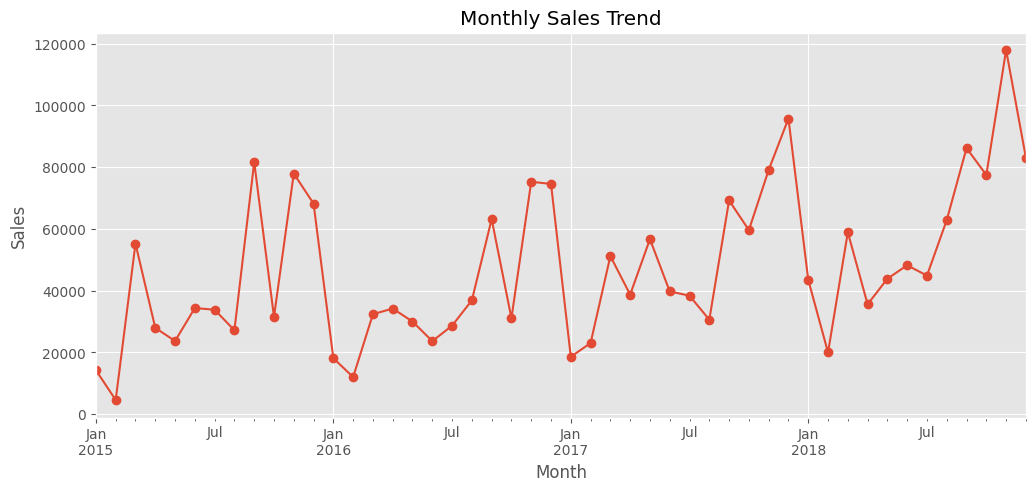

In [83]:
plt.figure()
monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.plot(figsize=(12,5), marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.savefig("Monthly_Sales_Trend.png", dpi=300, bbox_inches="tight")

plt.show()


# Quarterly Sales Trend

We analyze sales performance across quarters.

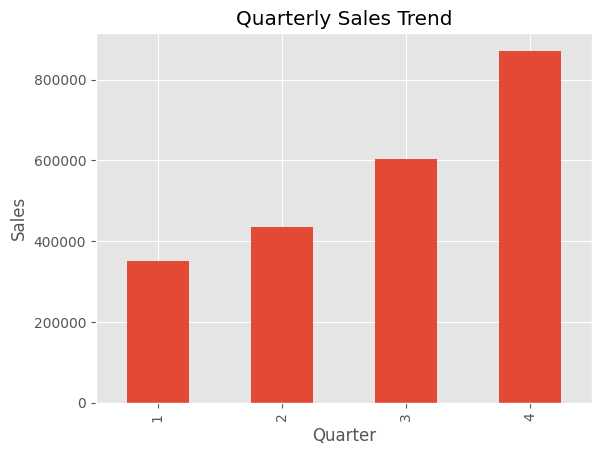

In [84]:
df.groupby("Quarter")["Sales"].sum().plot(kind="bar")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.savefig("Quarterly_Sales_Trend.png", dpi=300, bbox_inches="tight")

plt.show()

# Regional Analysis

We compare sales across different regions.

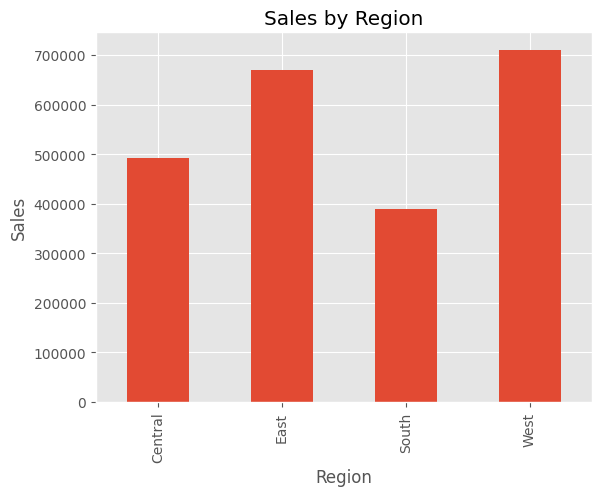

In [85]:
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.savefig("Regional_Analysis.png", dpi=300, bbox_inches="tight")

plt.show()

# State-wise Analysis

Top performing states based on sales.

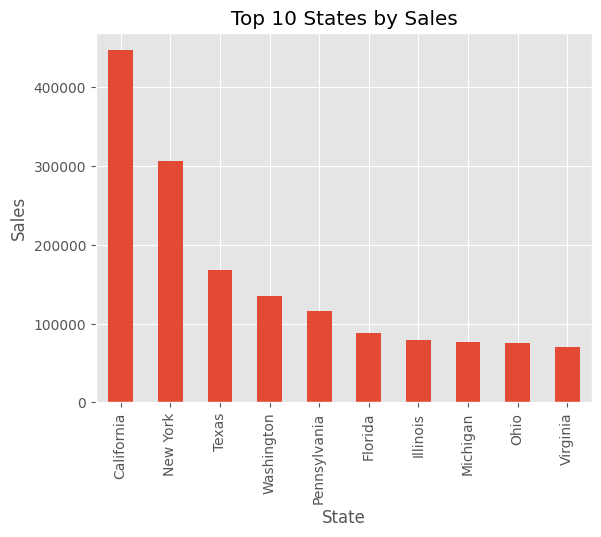

In [86]:
df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")
plt.savefig("State-wise_Analysis.png", dpi=300, bbox_inches="tight")

plt.show()

# Category Analysis

We analyze sales across product categories.

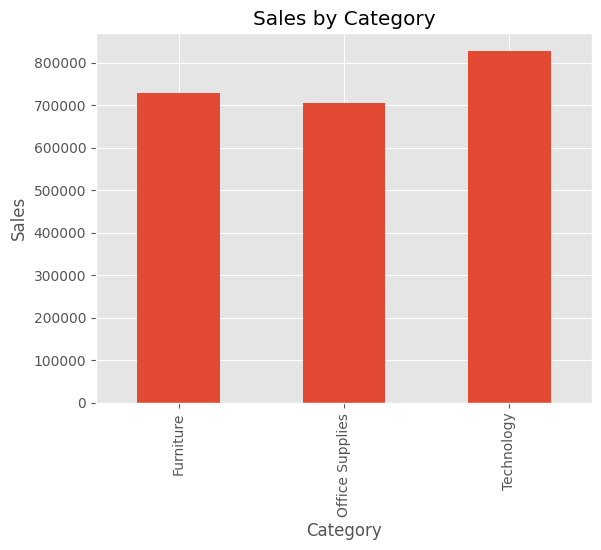

In [87]:
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.savefig("Category_Analysis.png", dpi=300, bbox_inches="tight")

plt.show()

# Sub-Category Analysis

We identify best performing sub-categories.

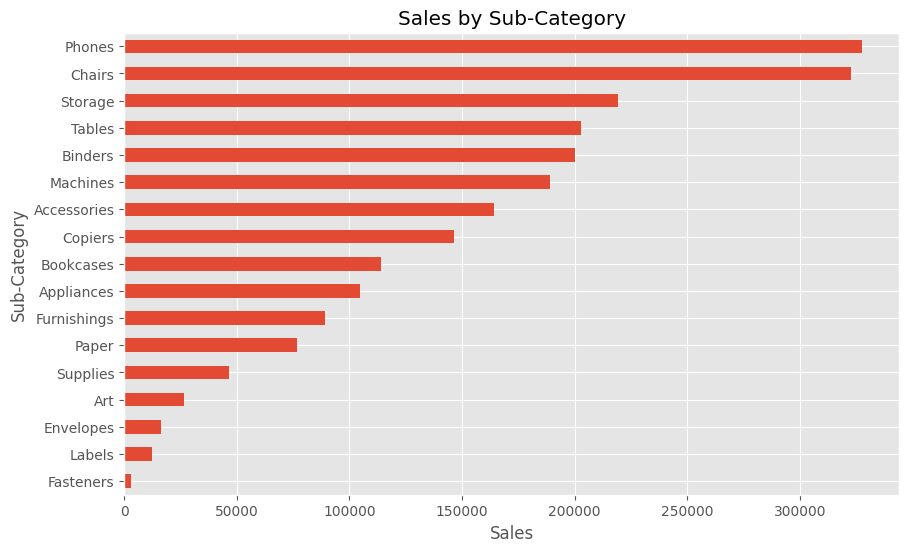

In [88]:
df.groupby("Sub_Category")["Sales"].sum().sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")
plt.savefig("Sub-Category_Analysis.png", dpi=300, bbox_inches="tight")

plt.show()

# Customer Segment Analysis

We analyze sales by customer segment.

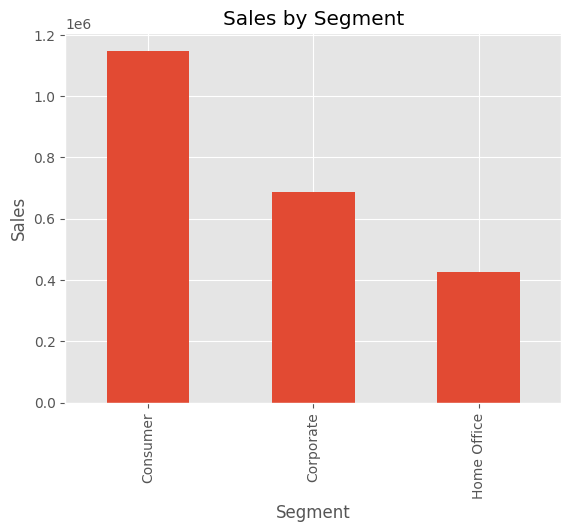

In [89]:
df.groupby("Segment")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.savefig("Customer_Segment_Analysis.png", dpi=300, bbox_inches="tight")

plt.show()

# Top 10 Products

Identifying highest revenue generating products.

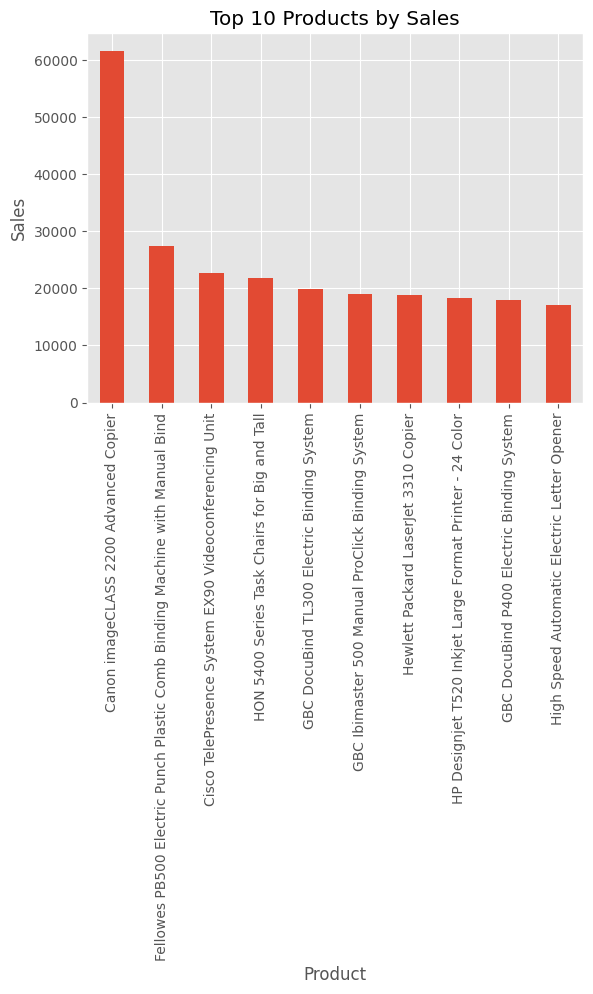

In [90]:
df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.savefig("Top10_Products.png", dpi=300, bbox_inches="tight")

plt.show()

## Sales Performance Over Time (Yearly Analysis)

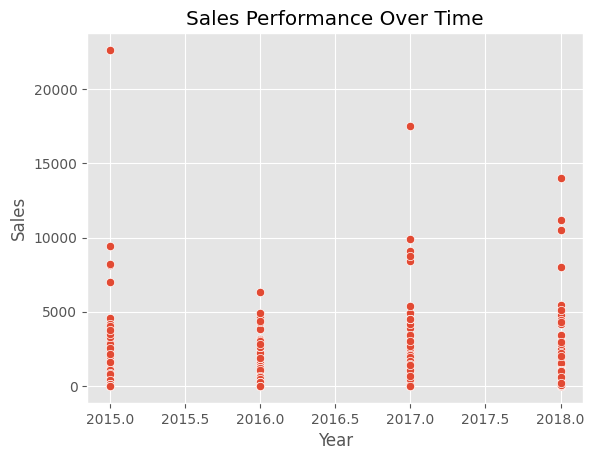

In [69]:
sns.scatterplot(data=df, x="Year", y="Sales")
plt.title("Sales Performance Over Time")
plt.show()

# Sales Distribution

Understanding distribution of sales values.

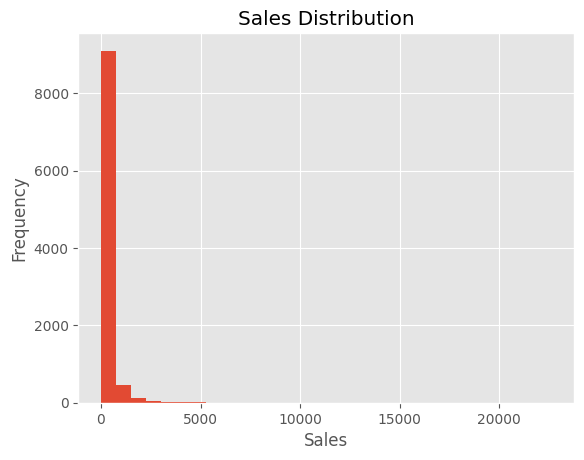

In [91]:
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.savefig("Sales_Distribution.png", dpi=300, bbox_inches="tight")

plt.show()

# Ship Mode Analysis

Understanding shipping preferences of customers.

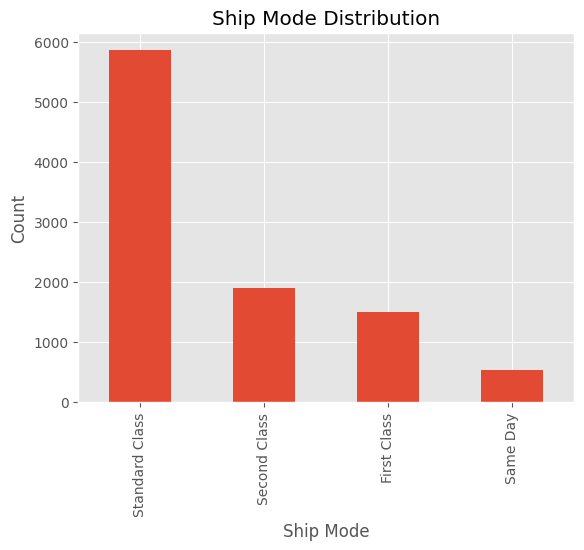

In [92]:
df["Ship_Mode"].value_counts().plot(kind="bar")
plt.title("Ship Mode Distribution")
plt.xlabel("Ship Mode")
plt.ylabel("Count")
plt.savefig("Ship_Mode_Analysis.png", dpi=300, bbox_inches="tight")

plt.show()

# Seasonality Analysis

We analyze monthly sales patterns.

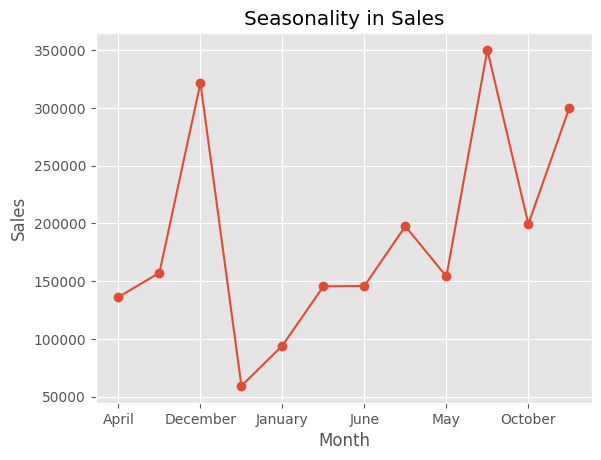

In [93]:
df.groupby("Month")["Sales"].sum().plot(kind="line", marker="o")
plt.title("Seasonality in Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.savefig("Seasonality_Analysis.png", dpi=300, bbox_inches="tight")

plt.show()

# Key Insights

- Sales vary across regions significantly.
- Certain categories dominate revenue contribution.
- Sub-categories like Phones and Chairs perform strongly.
- Discounts influence sales behavior.
- Clear seasonal trends exist in monthly sales.

# 5 Tactical Improvements for Alfido Tech Sales Strategy

Based on the sales analysis, the following actionable recommendations are suggested:

## 1. Focus on High-Performing Categories
Increase marketing and inventory allocation for top-performing categories such as high-revenue product segments to maximize overall sales.

## 2. Improve Low-Performing Regions
Identify regions with lower sales contribution and implement targeted promotions or localized campaigns to improve performance.

## 3. Optimize Product Portfolio
Reduce focus on consistently low-performing products and prioritize best-selling products to improve operational efficiency.

## 4. Strengthen Seasonal Planning
Use monthly and quarterly sales trends to plan inventory and marketing campaigns during peak sales periods.

## 5. Enhance Discount Strategy
Avoid unnecessary discounts that do not significantly increase sales volume and instead apply strategic discounting for selected products only.

# Business Recommendations

1. Focus on high-performing categories.
2. Improve marketing in low-performing regions.
3. Optimize discount strategy for better revenue.
4. Stock high-demand products more effectively.
5. Use seasonal trends for better planning.

# Conclusion

This project analyzed Superstore sales data using Python.

It included:
- Data cleaning
- Feature engineering
- KPI calculation
- Trend analysis
- Product and regional insights

The insights help improve business decisions and increase sales performance.